# Advanced Certification Program in Computational Data Science

##  A program by IISc and TalentSprint

### Mini Project Notebook: Bitcoin price forecasting using ARMA

## Learning Objectives

At the end of the experiment, you will be able to :

* perform EDA on time series data
* analyze the auto correlation and partial auto correlation plots
* implement the ARMA model and forecast the bit coin price

## Dataset



Bitcoin is a digital currency created in January 2009. It follows the ideas set out in a whitepaper by the mysterious and pseudonymous Satoshi Nakamoto. The identity of the person or persons who created the technology is still a mystery. Bitcoin offers the promise of lower transaction fees than traditional online payment mechanisms and, unlike government-issued currencies, it is operated by a decentralized authority.

Data Description
This dataset provides the history of daily prices of Bitcoin. The data starts from 17-Sep-2014 and is updated till 09-July-2021. All the column descriptions are provided below.

* Date: Day/Month/Year
* Open: Price from the first transaction of a trading day
* High: Maximum price in a trading day
* Low: Minimum price in a trading day
* Close: Price from the last transaction of a trading day
* Adj Close: Closing price adjusted to reflect the value after accounting for any corporate actions
* Volume: Number of units traded in a day

## Problem Statement

Perform EDA and forecast the Bitcoin price using ARMA model on timeseries (bitcoin) data.

## Grading = 10 Points

In [ ]:
#@title Download Dataset
!wget -qq !wget -qq https://cdn.iisc.talentsprint.com/CDS/MiniProjects/BTC.csv
print("Dataset downloaded successfully!!")

Dataset downloaded successfully!!


### Import required Packages 

In [ ]:
import warnings
warnings.simplefilter('ignore')
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from math import sqrt
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima_model import ARMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose 
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import statsmodels.api as sm
import itertools

### Load the data and perform EDA [2 points]

Hint: Refer to this ['Bitcoin dataset EDA'](https://medium.com/@hamzaahmad86/exploratory-data-analysis-of-cryptocurrency-historical-data-d8ec719641e7)

In [ ]:
# Read dataset
df = pd.read_csv('/content/BTC.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800.0
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200.0
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700.0
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600.0
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100.0


In [ ]:
# Convert Data column to datetime index
df['Date'] = pd.to_datetime(df['Date'])
df1 = df.set_index('Date')
df1.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800.0
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200.0
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700.0
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600.0
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100.0


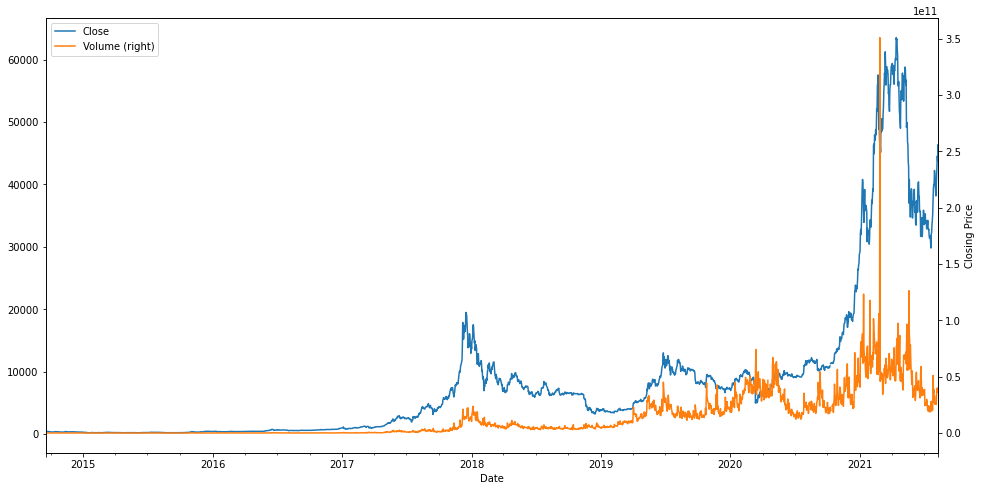

In [ ]:
# Visualize data
df1.plot(y=["Close","Volume"],secondary_y="Volume",figsize=(16,8))
plt.ylabel("Closing Price")
plt.show()
plt.close()

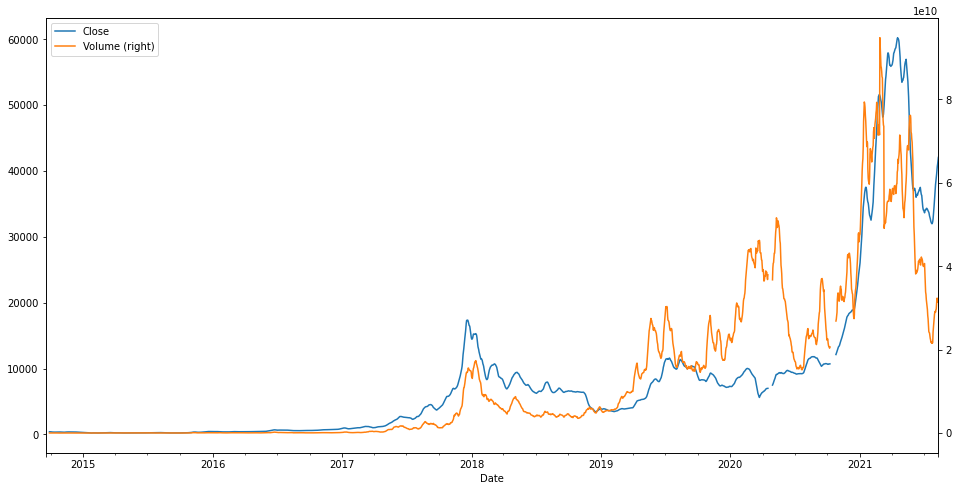

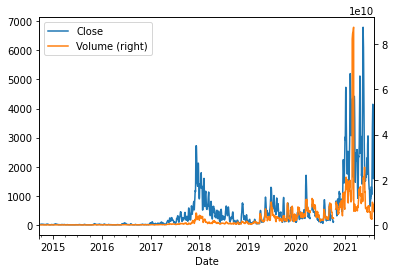

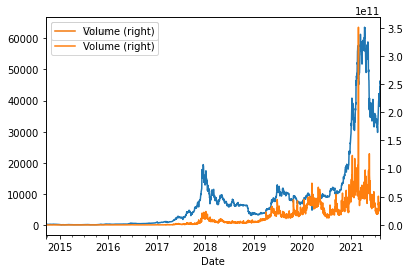

In [ ]:
# 12 month simple moving average and standard deviation
df1[['Close','Volume']].rolling(12).mean().plot(label='12 SMA',secondary_y="Volume",figsize=(16,8))
df1[['Close','Volume']].rolling(12).std().plot(secondary_y="Volume",label='12 STD')
df1[['Close','Volume']].plot(secondary_y="Volume")
plt.legend()
plt.show()
plt.close()

In [ ]:
df1.replace([np.inf, -np.inf], np.nan,inplace=True)

In [ ]:
df1.isna().sum().sum()

24

In [ ]:
len(df1)

2520

In [ ]:
abc = df1['Close'].quantile(0.5)
df1 = df1.fillna(abc)

#### Analyze the correlation (heatmap) of all the features

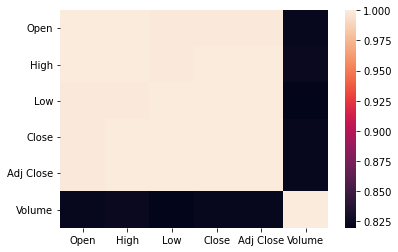

In [ ]:
df1_corr = df1[df1['Volume']<1e11].corr()
sns.heatmap(df1_corr)

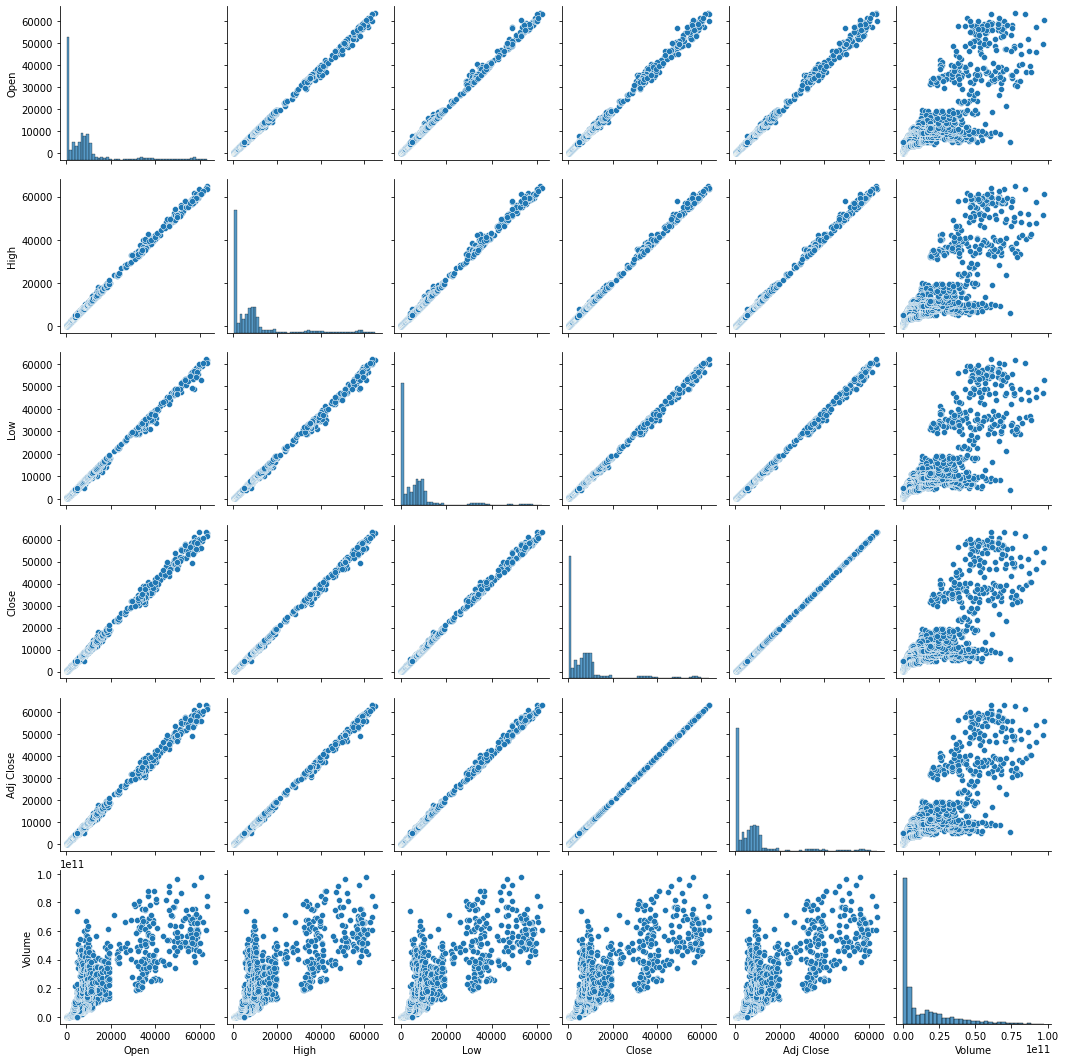

In [ ]:
sns.pairplot(df1[df1['Volume']<1e11])

### Test the Stationarity using Augmented Dicky Fuller Test [1 point]

The Augmented Dicky Fuller test is a type of statistical test called a unit root test.

Hint: [tsa.stattools.adfuller](https://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.adfuller.html)

In [ ]:
# Applying ADF test
fuller_test = adfuller(df1['Close'])
fuller_test

(-0.04944416841659578,
 0.9542470204821614,
 26,
 2493,
 {'1%': -3.4329757705711432,
  '5%': -2.862700050059295,
  '10%': -2.567387539813443},
 39640.85888243103)

In [ ]:
def test_p_value(data):
    """ Return Data is stationary if p-value <= 0.05 """

    fuller_test = adfuller(data)
    print('P-value: ',fuller_test[1])
    if fuller_test[1] <= 0.05:
        print('Reject null hypothesis, data is stationary')
    else:
        print('Do not reject null hypothesis, data is not stationary')

# ADF test for Production series
test_p_value(df1['Close'])

P-value:  0.9542470204821614
Do not reject null hypothesis, data is not stationary


### Identify the trends and seasonality from the given time series data [2 points]

* Apply seasonal decompose and plot the results
* Check the stationarity of data using rolling mean and rolling standard deviation.
* Make the time series data stationary
  * Apply a log transformation to reduce the variance of the series
  * Eliminate the Trend and Seasonality by Differencing 

**Note:** Ensure timeseries without NaN, inf, -inf values, Replace with 0 if found.

Read more about stationarity of a timeseries in the following [link](https://machinelearningmastery.com/time-series-data-stationary-python/)

In [ ]:
df1['Log_Close'] = np.log(df1['Close'])

In [ ]:
df1 = df1[~df1.isin([np.nan, np.inf, -np.inf]).any(1)]

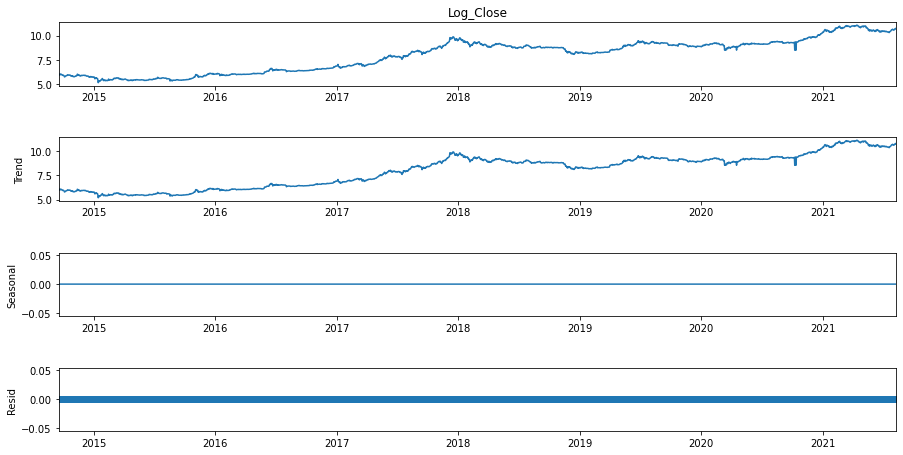

In [ ]:
# Decompose time series # Check the error for multiplicative - 0 and negative values
decomp = seasonal_decompose(x=df1['Log_Close'],model='additive', extrapolate_trend='freq', period=1)
fig = decomp.plot()
fig.set_size_inches(14,7)

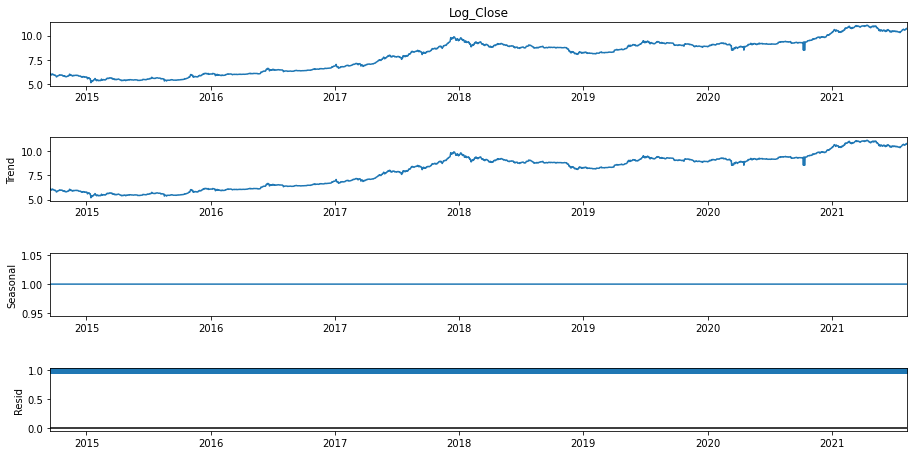

In [ ]:
# Decompose time series # Check the error for multiplicative - 0 and negative values
decomp = seasonal_decompose(x=df1['Log_Close'],model='multiplicative', extrapolate_trend='freq', period=1)
fig = decomp.plot()
fig.set_size_inches(14,7)

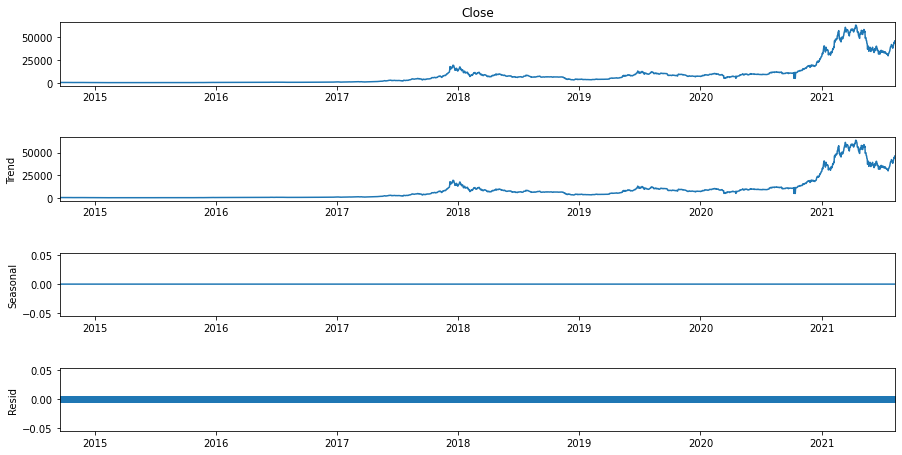

In [ ]:
# Decompose time series # Check the error for multiplicative - 0 and negative values
decomp = seasonal_decompose(x=df1['Close'],model='additive', extrapolate_trend='freq', period=1)
fig = decomp.plot()
fig.set_size_inches(14,7)

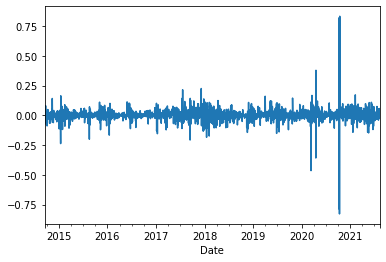

In [ ]:
# Perform First order differencing # Apply on the log transformation
#df1['Log_Close'] = np.log(df1['Close'])
df1['First_diff'] = df1['Log_Close'] - df1['Log_Close'].shift(1)
df1['First_diff'].plot()

In [ ]:
df1 = df1[~df1.isin([np.nan, np.inf, -np.inf]).any(1)]

### Test the Stationarity using Augmented Dicky Fuller Test [1 point]

Verify the stationarity post differencing, using ADF

Hint: [tsa.stattools.adfuller](https://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.adfuller.html)

In [ ]:
df1.describe()

,Open,High,Low,Close,Adj Close,Volume,Log_Close,First_diff
count,2519.000000,2519.000000,2519.000000,2519.000000,2519.000000,2.519000e+03,2519.000000,2519.000000
mean,8365.737378,8606.503194,8102.744455,8382.576783,8382.576783,1.312741e+10,7.970074,0.001825
std,12372.163946,12761.477085,11922.373235,12391.426772,12391.426772,1.978408e+10,1.639759,0.052264
min,176.897003,211.731003,171.509995,178.102997,178.102997,4.971905e+03,5.182362,-0.828422
25%,570.162018,576.294494,564.509491,571.388001,571.388001,7.053560e+07,6.348067,-0.012913
50%,4971.905029,5063.159668,4860.354004,4971.905029,4971.905029,4.227580e+09,8.511558,0.001997
75%,9383.452637,9554.184082,9233.823731,9389.831543,9389.831543,2.024686e+10,9.147383,0.018097
max,63523.753906,64863.097656,62208.964844,63503.457031,63503.457031,3.509679e+11,11.058850,0.832395


In [ ]:
df1.replace([np.inf, -np.inf], np.nan,inplace=True)

In [ ]:
# ADF test for First order difference
#df1['First_diff'].fillna()
test_p_value(df1['First_diff'].fillna(0))

P-value:  0.0
Reject null hypothesis, data is stationary


### Auto Correlation Plot [1 point]

Autocorrelation refers to the degree of correlation between the values of the same variables across different observations in the data.  The concept of autocorrelation is most often discussed in the context of time series data in which observations occur at different points in time.

* Plot the auto correlation function (ACF and PACF)
* Analyse ACF and PACF plots and define AR (p) and MA(q) terms

Text(0.5, 1.0, 'Autocorrelation plot')

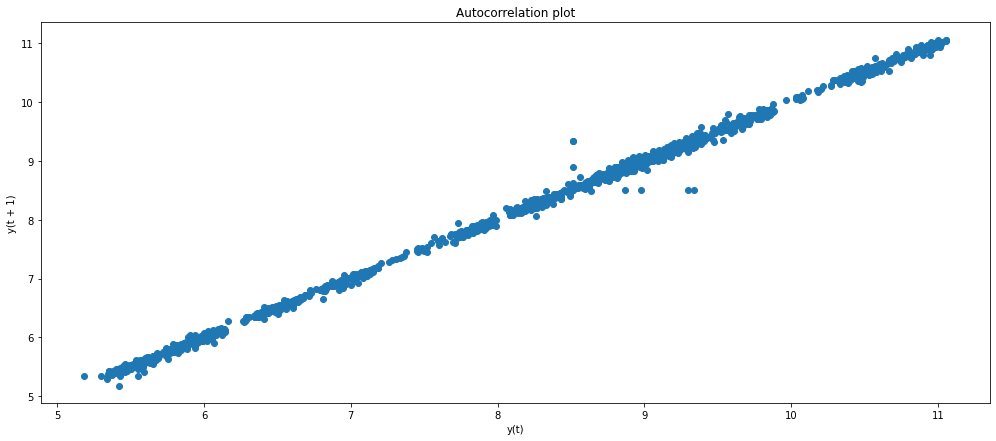

In [ ]:
# Lag Plot
from pandas.plotting import lag_plot
plt.figure(figsize=(17,7))
lag_plot(df1['Log_Close'], lag=1)
plt.title('Autocorrelation plot')

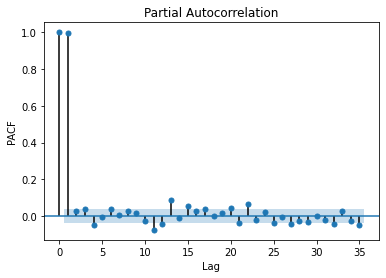

In [ ]:
# Visualize PACF
plot_pacf(df1['Close'])
plt.xlabel("Lag")
plt.ylabel("PACF")
plt.show()
plt.close()

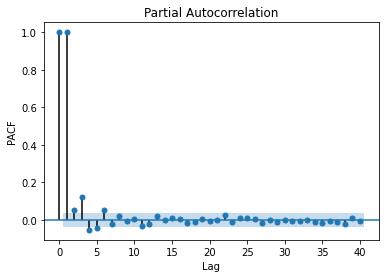

In [ ]:
plot_pacf(df1['Log_Close'],lags=40)
plt.xlabel("Lag")
plt.ylabel("PACF")
plt.show()
plt.close()

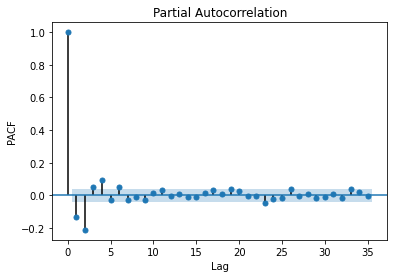

In [ ]:
# Visualize PACF on the First order difference
plot_pacf(df1['First_diff'])
plt.xlabel("Lag")
plt.ylabel("PACF")
plt.show()
plt.close()

In [ ]:
df1.tail()

,Open,High,Low,Close,Adj Close,Volume,Log_Close,First_diff
Date,,,,,,,,
2021-08-06,40865.867188,43271.660156,39932.179688,42816.500000,42816.500000,3.822648e+10,10.664679,0.046538
2021-08-07,42832.796875,44689.859375,42618.566406,44555.800781,44555.800781,4.003086e+10,10.704498,0.039819
2021-08-08,44574.437500,45282.351563,43331.910156,43798.117188,43798.117188,3.630266e+10,10.687346,-0.017152
2021-08-09,43791.925781,46456.832031,42848.687500,46365.402344,46365.402344,3.873408e+10,10.744309,0.056963
2021-08-10,46274.191406,46503.171875,45359.714844,45421.683594,45421.683594,3.662346e+10,10.723745,-0.020564


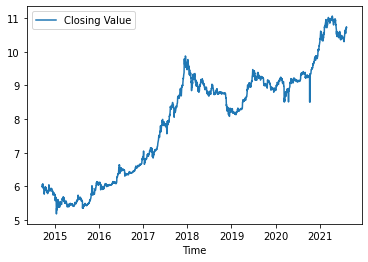

In [ ]:
# Visualize data
plt.plot(df1['Log_Close'], label="Closing Value")
plt.xlabel("Time")
plt.legend()
plt.show()
plt.close()

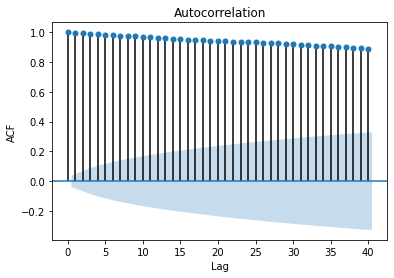

In [ ]:
# Visualize ACF
plot_acf(df1['Close'],lags=40)
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.show()
plt.close()

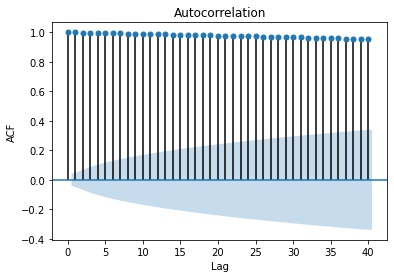

In [ ]:
# Visualize ACF
plot_acf(df1['Log_Close'],lags=40)
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.show()
plt.close()

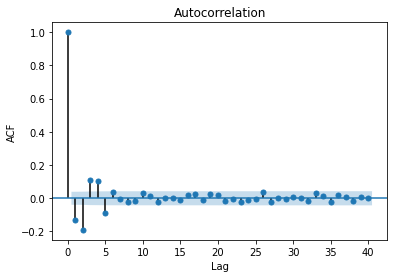

In [ ]:
# Visualize ACF on First Diff
plot_acf(df1['First_diff'],lags=40)
plt.xlabel("Lag")
plt.ylabel("ACF")
plt.show()
plt.close()

### Train the Auto Regressive model [1 point]

Hint: sm.tsa.AR()

In [ ]:
df1.head()

,Open,High,Low,Close,Adj Close,Volume,Log_Close,First_diff
Date,,,,,,,,
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200.0,6.050771,-0.074643
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700.0,5.978369,-0.072402
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600.0,6.013480,0.035111
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100.0,5.988513,-0.024968
2014-09-22,399.100006,406.915985,397.130005,402.152008,402.152008,24127600.0,5.996830,0.008317


In [ ]:
df2 = pd.read_csv('/content/BTC.csv')
df2['Date'] = pd.to_datetime(df2['Date'],format='%Y-%m')
df2 = df2.set_index('Date')
df2.head()
df2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2520 entries, 2014-09-17 to 2021-08-10
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       2516 non-null   float64
 1   High       2516 non-null   float64
 2   Low        2516 non-null   float64
 3   Close      2516 non-null   float64
 4   Adj Close  2516 non-null   float64
 5   Volume     2516 non-null   float64
dtypes: float64(6)
memory usage: 137.8 KB


In [ ]:
df2 = df2.drop(columns=['Open','High','Low','Adj Close','Volume'],axis=1)
df2 = df2.fillna(0)
df2.tail()

,Close
Date,
2021-08-06,42816.500000
2021-08-07,44555.800781
2021-08-08,43798.117188
2021-08-09,46365.402344
2021-08-10,45421.683594


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2520 entries, 2014-09-17 to 2021-08-10
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2520 non-null   float64
dtypes: float64(1)
memory usage: 39.4 KB


In [ ]:
df2.tail()

,Close
Date,
2021-08-06,42816.500000
2021-08-07,44555.800781
2021-08-08,43798.117188
2021-08-09,46365.402344
2021-08-10,45421.683594


/usr/local/lib/python3.7/dist-packages/statsmodels/tsa/base/tsa_model.py:527: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  % freq, ValueWarning)


<Figure size 1080x1080 with 0 Axes>

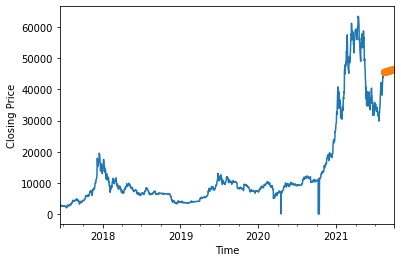

In [ ]:
# Create an AR model
regr = sm.tsa.AR(df2['Close']).fit(maxlag=2)
# Predict next 50 instances
fore = regr.predict(start=len(df2['Close']), end=len(df2['Close']) + 50)

# Visualize forecasts
plt.figure(figsize=(15,15))
df2[1000:].plot(xlabel="Time", ylabel="Closing Price", legend=False)
fore.plot(marker="o")
plt.show()
plt.close()

In [ ]:
fore

In [ ]:
# Create an AR model
#df1['Log_Close'] = np.log(df1['Close'])
regr = sm.tsa.AR(df1['Log_Close']).fit(maxlag=2)
# Predict next 50 instances
fore = np.exp(regr.predict(start=len(df1['Log_Close']), end=len(df1['Log_Close']) + 50))

/usr/local/lib/python3.7/dist-packages/statsmodels/tsa/base/tsa_model.py:527: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  % freq, ValueWarning)


In [ ]:
df1.head()

,Open,High,Low,Close,Adj Close,Volume,Log_Close,First_diff
Date,,,,,,,,
2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200.0,6.050771,-0.074643
2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700.0,5.978369,-0.072402
2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600.0,6.013480,0.035111
2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100.0,5.988513,-0.024968
2014-09-22,399.100006,406.915985,397.130005,402.152008,402.152008,24127600.0,5.996830,0.008317


In [ ]:
# Visualize forecasts
plt.figure(figsize=(15,15))
#df1.plot(y='Close',x=df1.Log_Close, xlabel="Time", ylabel="Closing Price", legend=False)
#plt.plot(df1["Close"],data=df1)
fore.plot()
plt.show()
#plt.close()

In [ ]:
fore

### ARMA Model [1 point]

* Train the ARMA model on timeseries data and print AIC value

In [ ]:
# Create ARMA(p=6, q=4) model
arm = sm.tsa.ARIMA(df1['Log_Close'], order=(1,1,0))
r2 = arm.fit()
print(r2.summary())

                             ARIMA Model Results                              
Dep. Variable:            D.Log_Close   No. Observations:                 2518
Model:                 ARIMA(1, 1, 0)   Log Likelihood                3882.759
Method:                       css-mle   S.D. of innovations              0.052
Date:                Sun, 28 Aug 2022   AIC                          -7759.517
Time:                        12:17:44   BIC                          -7742.024
Sample:                    09-19-2014   HQIC                         -7753.169
                         - 08-10-2021                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0019      0.001      2.045      0.041    7.73e-05       0.004
ar.L1.D.Log_Close    -0.1341      0.020     -6.790      0.000      -0.173      -0.095
                        

/usr/local/lib/python3.7/dist-packages/statsmodels/tsa/base/tsa_model.py:527: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  % freq, ValueWarning)
/usr/local/lib/python3.7/dist-packages/statsmodels/tsa/base/tsa_model.py:527: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  % freq, ValueWarning)


In [ ]:
r2.aic

-7759.517264773302

In [ ]:
# Create ARMA(p=1, q=5) model
df1['First_diff'] = df1['First_diff'].fillna(0)
arm3 = sm.tsa.ARIMA(df1.Log_Close, order=(6,1,4))
r4 = arm3.fit()
print(r4.summary())

/usr/local/lib/python3.7/dist-packages/statsmodels/tsa/base/tsa_model.py:527: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  % freq, ValueWarning)
/usr/local/lib/python3.7/dist-packages/statsmodels/tsa/base/tsa_model.py:527: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  % freq, ValueWarning)


                             ARIMA Model Results                              
Dep. Variable:            D.Log_Close   No. Observations:                 2518
Model:                 ARIMA(6, 1, 4)   Log Likelihood                3966.131
Method:                       css-mle   S.D. of innovations              0.050
Date:                Sun, 28 Aug 2022   AIC                          -7908.262
Time:                        12:17:58   BIC                          -7838.287
Sample:                    09-19-2014   HQIC                         -7882.867
                         - 08-10-2021                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0019      0.001      2.293      0.022       0.000       0.003
ar.L1.D.Log_Close     0.2924      0.383      0.764      0.445      -0.458       1.043
ar.L2.D.Log_Close    -0.

In [ ]:
r4.aic

-7908.261900448935

In [ ]:
!pip install pmdarima

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 1.8 MB 11.4 MB/s 
     |████████████████████████████████| 9.8 MB 57.4 MB/s 
  Attempting uninstall: statsmodels
    Found existing installation: statsmodels 0.12.2
    Uninstalling statsmodels-0.12.2:
      Successfully uninstalled statsmodels-0.12.2


In [ ]:
# Fit the model
import pmdarima as pm
model = pm.auto_arima(df1.Log_Close, seasonal=False,m=0) # m is seasonal term

# Make forecast
forecasts = model.predict()  # predict 1 step into the future

In [ ]:
# Model summary
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2519
Model:               SARIMAX(4, 1, 1)   Log Likelihood                3959.509
Date:                Sun, 28 Aug 2022   AIC                          -7905.018
Time:                        12:19:19   BIC                          -7864.199
Sample:                    09-18-2014   HQIC                         -7890.204
                         - 08-10-2021                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0036      0.002      1.937      0.053    -4.2e-05       0.007
ar.L1         -0.7429      0.076     -9.762      0.000      -0.892      -0.594
ar.L2         -0.2747      0.020    -13.620      0.000      -0.314      -0.235
ar.L3         -0.0555      0.027     -2.050      0.040      -0.109      -0.002
ar.L4          0.1191      0.011     10.446      0.000       0.097       0.141
ma.L1          0.5942      0.076      7.839      0.000       0.446       0.743
sigma2         0.0025   1.81e-05    139.317      0.000       0.002       0.003
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):            384455.72
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               4.27   Skew:                            -1.05
Prob(H) (two-sided):                  0.00   Kurtosis:                        63.50
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

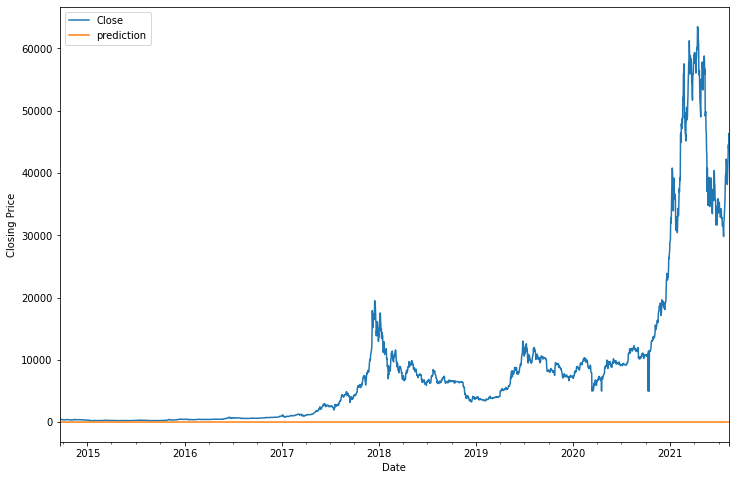

In [ ]:
# Predict present data
df1['prediction'] = r2.predict()
df1[['Close','prediction']].plot(figsize=(12,8))
plt.ylabel("Closing Price")
plt.show()
plt.close()

In [ ]:
df1.tail()

,Open,High,Low,Close,Adj Close,Volume,Log_Close,First_diff,prediction
Date,,,,,,,,,
2021-08-06,40865.867188,43271.660156,39932.179688,42816.500000,42816.500000,3.822648e+10,10.664679,0.046538,-0.001624
2021-08-07,42832.796875,44689.859375,42618.566406,44555.800781,44555.800781,4.003086e+10,10.704498,0.039819,-0.004132
2021-08-08,44574.437500,45282.351563,43331.910156,43798.117188,43798.117188,3.630266e+10,10.687346,-0.017152,-0.003230
2021-08-09,43791.925781,46456.832031,42848.687500,46365.402344,46365.402344,3.873408e+10,10.744309,0.056963,0.004410
2021-08-10,46274.191406,46503.171875,45359.714844,45421.683594,45421.683594,3.662346e+10,10.723745,-0.020564,-0.005530


In [ ]:
from pandas.tseries.offsets import DateOffset
# Create extra index dates
extra_dates = [df1.index[-1] + DateOffset(days=d) for d in range (1,25)]
extra_dates

[Timestamp('2021-08-11 00:00:00'),
 Timestamp('2021-08-12 00:00:00'),
 Timestamp('2021-08-13 00:00:00'),
 Timestamp('2021-08-14 00:00:00'),
 Timestamp('2021-08-15 00:00:00'),
 Timestamp('2021-08-16 00:00:00'),
 Timestamp('2021-08-17 00:00:00'),
 Timestamp('2021-08-18 00:00:00'),
 Timestamp('2021-08-19 00:00:00'),
 Timestamp('2021-08-20 00:00:00'),
 Timestamp('2021-08-21 00:00:00'),
 Timestamp('2021-08-22 00:00:00'),
 Timestamp('2021-08-23 00:00:00'),
 Timestamp('2021-08-24 00:00:00'),
 Timestamp('2021-08-25 00:00:00'),
 Timestamp('2021-08-26 00:00:00'),
 Timestamp('2021-08-27 00:00:00'),
 Timestamp('2021-08-28 00:00:00'),
 Timestamp('2021-08-29 00:00:00'),
 Timestamp('2021-08-30 00:00:00'),
 Timestamp('2021-08-31 00:00:00'),
 Timestamp('2021-09-01 00:00:00'),
 Timestamp('2021-09-02 00:00:00'),
 Timestamp('2021-09-03 00:00:00')]

In [ ]:
# Create new dataframe with extra index dates
forecast_df = pd.DataFrame(index=extra_dates,columns=df1.columns)
forecast_df.head()

,Open,High,Low,Close,Adj Close,Volume,Log_Close,First_diff,prediction
2021-08-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-08-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-08-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-08-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-08-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Concat dataframes
final_df = pd.concat([df1,forecast_df])
final_df.tail()

,Open,High,Low,Close,Adj Close,Volume,Log_Close,First_diff,prediction
2021-08-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-09-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-09-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Plot the predictions for timeseries data [1 point]

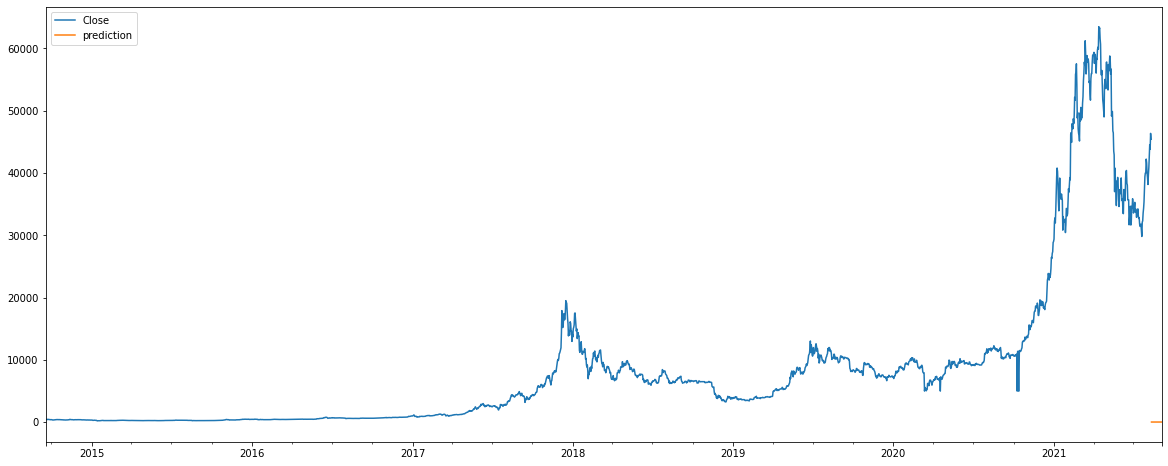

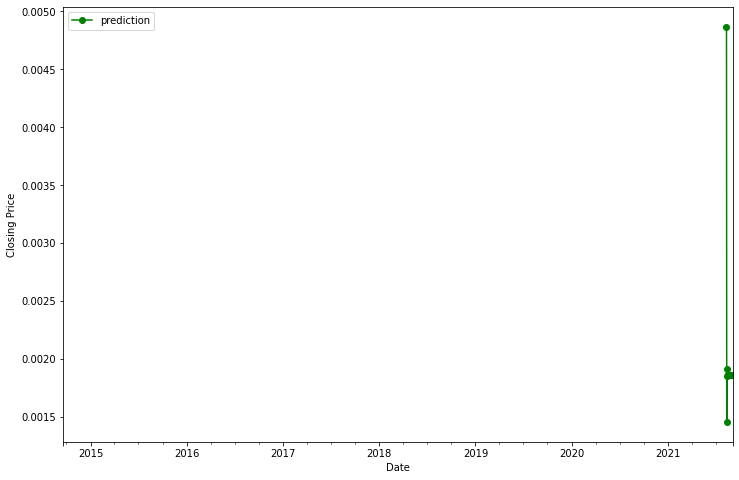

In [ ]:
# Visualize prediction for extra index dates
final_df['prediction'] = r2.predict(start=len(df1), end=len(df1)+25)
final_df[['Close','prediction']].plot(figsize=(20,8))
final_df[['prediction']].plot(figsize=(12,8),color='green',marker='o')
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

In [ ]:
final_df.tail()

,Open,High,Low,Close,Adj Close,Volume,Log_Close,First_diff,prediction
2021-08-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00186
2021-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00186
2021-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00186
2021-09-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00186
2021-09-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00186


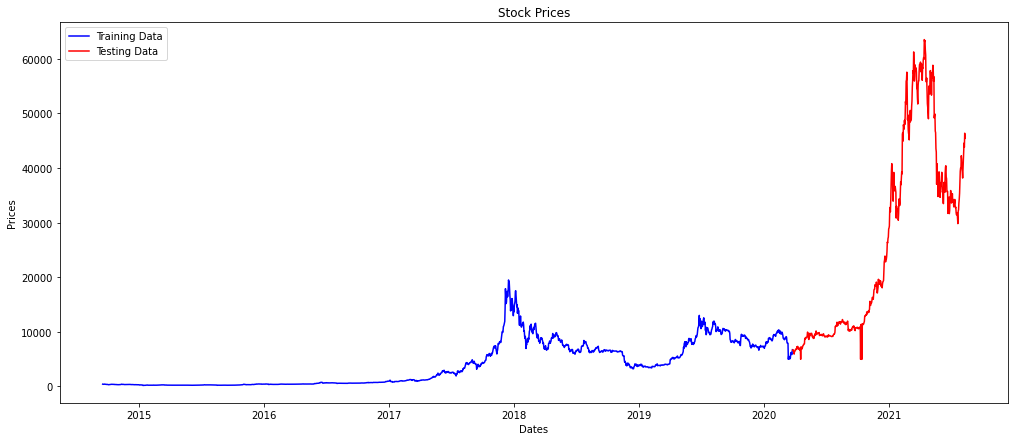

In [ ]:
train_data, test_data = df1[0:int(len(df1)*0.8)], df1[int(len(df1)*0.8):] # Train and test split
plt.figure(figsize=(17,7))
plt.title('Stock Prices')
plt.xlabel('Dates')
plt.ylabel('Prices')
plt.plot(train_data['Close'], 'blue', label='Training Data') #Plot train data in blue color
plt.plot(test_data['Close'], 'red', label='Testing Data')  # Plot test data in red color
#plt.xticks(np.arange(0,7982, 1300), df1['Date'][0:7982:1300])
plt.legend()
plt.show()

In [ ]:
# Function to Calculate the mean absolute percentage error
# The mean absolute percentage error (MAPE) is a statistical measure of how accurate a forecast system is.
# It measures this accuracy as a percentage, and can be calculated as the average absolute percent error for each time 
# period minus actual values divided by actual values
def  Mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [ ]:
# ARIMA model # Put the training outside the loop
train_ar = train_data['Close'].values
test_ar = test_data['Close'].values

history = [x for x in train_ar]
    
    
predictions = list()

for t in range(len(test_ar)):
    model = sm.tsa.ARIMA(history, order=(1,1,0))
    model_fit = model.fit(disp=0)
    #print(model_fit.aic,model_fit)
    # Above, disp=0 setting turns off the large amount of debug information provided
    # regarding the fit of the regression model.
    output = model_fit.forecast() # one-step forecast
    yhat = output[0]
    predictions.append(yhat)
    obs = test_ar[t]
    #history.append(obs) # Commenting out
    history.append(yhat) # Fixed the bug
    print('predicted=%f, expected=%f' % (yhat, obs))

predicted=6745.425101, expected=6681.062988
predicted=6748.739786, expected=6716.440430
predicted=6751.881059, expected=6469.798340
predicted=6755.018216, expected=6242.193848
predicted=6758.155275, expected=5922.042969
predicted=6761.292333, expected=6429.841797
predicted=6764.429390, expected=6438.644531
predicted=6767.566448, expected=6606.776367
predicted=6770.703505, expected=6793.624512
predicted=6773.840562, expected=6733.387207
predicted=6776.977619, expected=6867.527344
predicted=6780.114676, expected=6791.129395
predicted=6783.251733, expected=7271.781250
predicted=6786.388790, expected=7176.414551
predicted=6789.525847, expected=7334.098633
predicted=6792.662905, expected=7302.089355
predicted=6795.799962, expected=6865.493164
predicted=6798.937019, expected=6859.083008
predicted=6802.074076, expected=6971.091797
predicted=6805.211133, expected=6845.037598
predicted=6808.348190, expected=6842.427734
predicted=6811.485247, expected=6642.109863
predicted=6814.622304, expected=

In [ ]:
output

(array([46171.97327084]),
 array([702.78000273]),
 array([[44794.54977643, 47549.39676525]]))

In [ ]:
history

In [ ]:
error = Mean_absolute_percentage_error(test_ar, predictions)
print('Mean absolute percentage error: %.3f' % error)

Mean absolute percentage error: 54.111


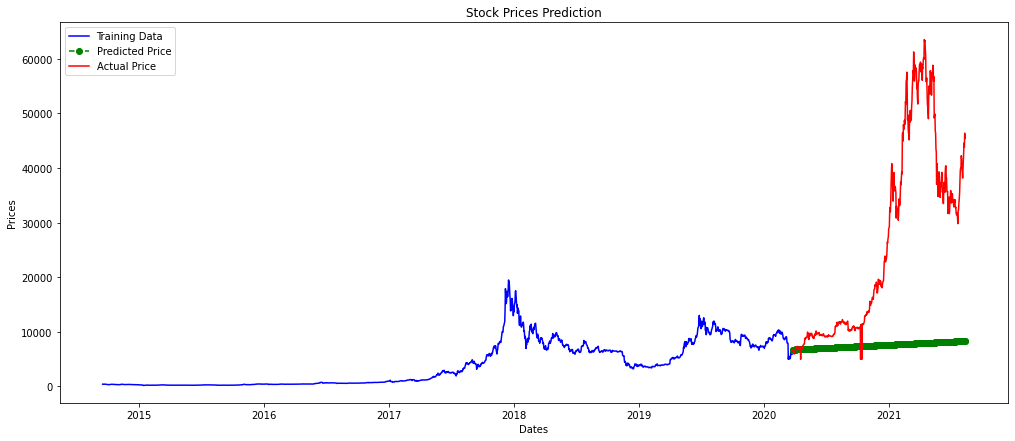

In [ ]:
# Plot the predictions
plt.figure(figsize=(17,7))
plt.plot(train_data['Close'], 'green', color='blue', label='Training Data')
plt.plot(test_data.index, predictions, color='green',marker='o', linestyle='dashed', label='Predicted Price')
plt.plot(test_data.index, test_data['Close'], color='red', label='Actual Price')
plt.title('Stock Prices Prediction')
plt.xlabel('Dates')
plt.ylabel('Prices')
#plt.xticks(np.arange(0,7982, 1300), df1['Date'][0:7982:1300])
plt.legend()

### Report Analysis

* Discuss how sudden effects of bitcoin price affects the model parameters
* State your observations about the trend and seasonality of the timeseries data
* Discuss how you selected ARMA (p and q) terms.
* Interpret the AIC value obtained for the ARMA model

In [ ]:
# Try out why the ARIMA model is within the for loop for the predictions and how it stops predicting if its outside the for loop
# Create python file and import the module instead of changing the code on the fly.